# K-Means Clustering

**K-Means Clustering** is an unsupervised learning algorithm used to divide data points into $K$ distinct clusters based on their similarity.

The algorithm tries to group points such that points within the same cluster are as close to each other as possible.

---

## 5 Steps of K-Means Clustering

The K-Means algorithm can be understood in five major steps:

```text id="kmeanssteps"
1. Decide the number of clusters (K)
              ↓
2. Initialize centroids
              ↓
3. Assign clusters
              ↓
4. Move centroids
              ↓
5. Repeat until convergence
```

---

# 1. Decide the Number of Clusters

First, we need to decide the value of $K$.

For example:

$$
K = 3
$$

This means that we want to divide the dataset into **3 clusters**.

```mermaid id="4x4yqa"
flowchart LR
    D["Dataset"] --> K["Choose K = 3"]
    K --> C["3 Clusters"]
```

The choice of $K$ is important because it determines how many groups the algorithm will create.

Common methods for choosing $K$ include:

* **Elbow Method**
* **Silhouette Score**
* **Domain Knowledge**

---

# 2. Initialize the Centroids

Once $K$ is selected, we initialize $K$ centroids.

For:

$$
K = 3
$$

we initialize:

$$
C_1,\ C_2,\ C_3
$$

These centroids can initially be placed randomly within the feature space.

```text id="centroids"
              y
              ↑
              |
       ●      |              ●
              |
              |
              |        ●
              |
              └────────────────────→ x
```

The initial centroid positions will generally not be optimal.

K-Means will iteratively move them toward better positions.

---

# 3. Assign Each Point to a Cluster

For every data point, calculate its distance from each centroid.

The most commonly used distance is **Euclidean distance**:

$$
d(x,c)=
\sqrt{
\sum_{j=1}^{n}(x_j-c_j)^2
}
$$

For a 2-dimensional point:

$$
d((x_1,x_2),(c_1,c_2))
======================

\sqrt{
(x_1-c_1)^2+(x_2-c_2)^2
}
$$

Each point is assigned to the cluster whose centroid is closest.

```mermaid id="assigncluster"
flowchart LR
    X["Data Point"] --> D1["Distance to C₁"]
    X --> D2["Distance to C₂"]
    X --> D3["Distance to C₃"]

    D1 --> MIN["Choose Minimum Distance"]
    D2 --> MIN
    D3 --> MIN

    MIN --> C["Assign Cluster"]
```

Mathematically, the cluster assignment is:

$$
\text{cluster}(x_i)
===================

\arg\min_{k}
\ d(x_i,c_k)
$$

---

# 4. Move the Centroids

After assigning all points to clusters, we calculate the new centroid of each cluster.

The centroid is simply the **mean of all points belonging to that cluster**.

For a cluster containing $n$ points:

$$
C =
\frac{1}{n}
\sum_{i=1}^{n}x_i
$$

For two-dimensional data:

$$
C_x =
\frac{1}{n}
\sum_{i=1}^{n}x_i
$$

$$
C_y =
\frac{1}{n}
\sum_{i=1}^{n}y_i
$$

Therefore:

$$
C=(C_x,C_y)
$$

The centroids move from their previous positions toward the center of their assigned points.

---

# 5. Repeat Until Convergence

After moving the centroids, we again assign every point to the nearest centroid.

Therefore, the process becomes:

```text id="iteration"
Initialize Centroids
       ↓
Assign Points
       ↓
Calculate New Centroids
       ↓
Assign Points Again
       ↓
Calculate New Centroids
       ↓
      ...
       ↓
Convergence
```

The algorithm continues until the centroids stop changing significantly or the assignments stop changing.

---

# K-Means Algorithm

The complete algorithm can be summarized as:

```mermaid id="completekmeans"
flowchart TD
    START["Start"] --> K["Choose K"]
    K --> INIT["Initialize K Centroids"]
    INIT --> ASSIGN["Assign Each Point<br/>to Nearest Centroid"]
    ASSIGN --> UPDATE["Calculate New Centroids"]
    UPDATE --> CHECK{"Centroids<br/>Changed?"}
    CHECK -->|Yes| ASSIGN
    CHECK -->|No| END["Converged"]
```

---

# Objective Function

K-Means tries to minimize the **Within-Cluster Sum of Squares (WCSS)**.

The objective function is:

$$
J =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
|x_i-\mu_k|^2
$$

where:

* $K$ = number of clusters
* $C_k$ = $k$-th cluster
* $x_i$ = data point
* $\mu_k$ = centroid of cluster $k$
* $|x_i-\mu_k|^2$ = squared Euclidean distance between the point and its centroid

The goal is:

$$
\boxed{
\min J
}
$$

In simple terms:

> **K-Means tries to position the centroids so that the total squared distance between each point and its assigned centroid is minimized.**

---

# Visual Representation

For a dataset with:

$$
K=3
$$

we may initially observe groups such as:

```text id="visual"
                  y
                  ↑

       ○ ○ ○
      ○ ○ ○

                            ○ ○ ○
                           ○ ○ ○

                ○ ○ ○
               ○ ○ ○

                  └──────────────────→ x
```

After applying K-Means, the points are assigned to three clusters:

```text id="clusters"
                  y
                  ↑

       ● ● ●                 ▲ ▲ ▲
      ● ● ●                 ▲ ▲ ▲
       ● ●

                   ■ ■ ■
                  ■ ■ ■

                  └──────────────────→ x
```

Here:

* `●` → Cluster 1
* `▲` → Cluster 2
* `■` → Cluster 3

Each cluster has its own centroid.

---

# Choosing the Value of K — Elbow Method

One of the most common ways to select $K$ is the **Elbow Method**.

We calculate WCSS for different values of $K$:

$$
K=1,2,3,\ldots,n
$$

and plot:

$$
K \quad \text{vs} \quad WCSS
$$

Typically, WCSS decreases as $K$ increases.

The optimal value of $K$ is often chosen around the point where the rate of decrease starts becoming significantly smaller.

```text id="elbow"
WCSS
 │
 │\
 │ \
 │  \
 │   \
 │    \__
 │       \____
 │
 └────────────────→ K
          ↑
        Elbow
```

The point where the curve starts to flatten is called the **elbow point**.

---

# Important Characteristics of K-Means

| Property              | Description                 |
| --------------------- | --------------------------- |
| Learning Type         | Unsupervised Learning       |
| Algorithm Type        | Clustering                  |
| Number of Clusters    | Must specify $K$            |
| Distance Metric       | Usually Euclidean Distance  |
| Centroid              | Mean of points in a cluster |
| Objective             | Minimize WCSS               |
| Sensitive to Scale    | Yes                         |
| Sensitive to Outliers | Yes                         |
| Initialization        | Usually random or K-Means++ |

---

# Important Considerations

### 1. Feature Scaling

K-Means is distance-based, so feature scaling is usually important.

For example, if one feature ranges from:

$$
0-100000
$$

and another ranges from:

$$
0-10
$$

the larger-scale feature can dominate the distance calculation.

Therefore, techniques such as:

* `StandardScaler`
* `MinMaxScaler`

are commonly used before K-Means.

---

### 2. Initialization Matters

Different initial centroid positions can lead to different final clusters.

To reduce this problem, **K-Means++** is commonly used for centroid initialization.

```python
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=42
)
```

---

### 3. Outliers

K-Means is sensitive to outliers because the centroid is calculated using the **mean**.

A single extreme point can significantly shift the centroid.

---

# Complete Concept

The complete K-Means process is:

$$
\boxed{
\text{Choose }K
\rightarrow
\text{Initialize Centroids}
\rightarrow
\text{Assign Points}
\rightarrow
\text{Move Centroids}
\rightarrow
\text{Repeat}
\rightarrow
\text{Convergence}
}
$$

The central idea is:

> **Assign each point to its nearest centroid, recompute the centroids using the assigned points, and repeat this process until the clusters stabilize.**


# Now we will have to decide the value of k that the number of clusters that are needed
## For that we use the Elbon method
- It is the graph between the no of clusters and WCSS which is the within circle sum of square


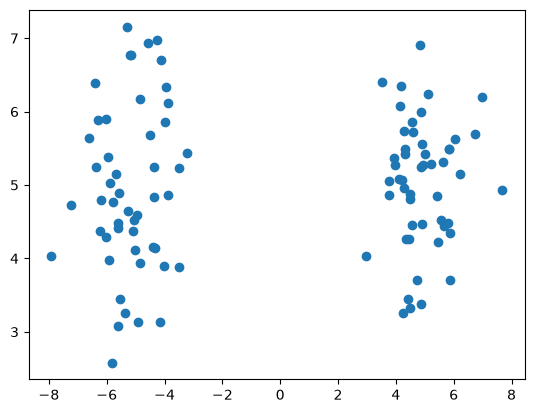

In [3]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
centroids=[(-5,5),(5,5)]
cluster_std=[1,1]
X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=3)
plt.scatter(X[:,0],X[:,1])
plt.show()